# Bitcoin (BTC/USD) Historical Price Analysis

## Patterns & Insights from Minute-Level Trading Data

### Research Question

**What patterns and trends can we identify in Bitcoin's historical price behavior, and can we build a baseline model to predict short-term price direction?**

This notebook is beginner-friendly and focuses on:

1. Loading and understanding the data
2. Exploring patterns with Seaborn visualizations
3. Building a simple baseline machine learning model
4. Interpreting findings clearly

## Setup

If needed, run the next cell to install required libraries in the notebook kernel.

In [ ]:
# Uncomment and run if you are missing packages.
# %pip install seaborn scikit-learn

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

## Load Dataset

The dataset contains minute-level BTC/USD trading data with columns: Timestamp, Open, High, Low, Close, and Volume.

In [ ]:
# Upload the CSV when running on Google Colab
try:
    import google.colab
    from google.colab import files
    print("Running on Colab — please upload btcusd_1-min_data.csv")
    uploaded = files.upload()
    data_path = Path(list(uploaded.keys())[0])
except ImportError:
    data_path = Path("btcusd_1-min_data.csv")

df_raw = pd.read_csv(data_path)
print("Shape:", df_raw.shape)
df_raw.head()

Running on Colab — please upload btcusd_1-min_data.csv


Saving btcusd_1-min_data.csv to btcusd_1-min_data.csv
Shape: (7486242, 6)


,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


## Quick Data Check

We will inspect column names, missing values, and data types before any analysis.

In [ ]:
print("Total rows:", len(df_raw))
print("Total columns:", len(df_raw.columns))

missing_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)
print("\nMissing percentage per column:")
display(missing_pct.to_frame("missing_%"))

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

Total rows: 7486242
Total columns: 6

Missing percentage per column:


,missing_%
Timestamp,0.0
Open,0.0
High,0.0
Low,0.0
Close,0.0
Volume,0.0



Data types:


,dtype
Timestamp,float64
Open,float64
High,float64
Low,float64
Close,float64
Volume,float64


## Data Preparation

The raw dataset has ~7.5 million rows at minute-level granularity. We will:

1. Convert the Unix timestamp to a proper datetime
2. Drop rows with missing price data
3. Resample to **daily OHLCV** bars for faster analysis and clearer trends

In [ ]:
# Convert Unix timestamp to datetime and set as index
df_raw["Timestamp"] = pd.to_datetime(df_raw["Timestamp"], unit="s")
df_raw = df_raw.set_index("Timestamp")

# Drop rows where all OHLC values are missing
df_raw = df_raw.dropna(subset=["Close"])

print(f"Date range: {df_raw.index.min()} to {df_raw.index.max()}")
print(f"Rows after dropping missing Close: {len(df_raw):,}")

# Resample to daily OHLCV bars
df = df_raw.resample("D").agg(
    {"Open": "first", "High": "max", "Low": "min", "Close": "last", "Volume": "sum"}
).dropna(subset=["Close"])

print(f"\nDaily bars: {len(df):,}")
df.head()

Date range: 2012-01-01 10:01:00 to 2026-03-28 00:02:00
Rows after dropping missing Close: 7,486,242

Daily bars: 5,201


,Open,High,Low,Close,Volume
Timestamp,,,,,
2012-01-01,4.58,4.84,4.58,4.84,10.000000
2012-01-02,4.84,5.00,4.84,5.00,10.100000
2012-01-03,5.00,5.32,5.00,5.29,107.085281
2012-01-04,5.29,5.57,4.93,5.57,107.233260
2012-01-05,5.57,6.46,5.57,6.42,70.328742


## Feature Engineering

We create several derived columns that will be useful for both EDA and modeling.

In [ ]:
# Daily return (percentage change)
df["Daily_Return"] = df["Close"].pct_change() * 100

# Intraday range as a percentage of the opening price
df["Intraday_Range_Pct"] = ((df["High"] - df["Low"]) / df["Open"]) * 100

# Rolling 30-day moving average
df["MA_30"] = df["Close"].rolling(30).mean()

# Rolling 30-day volatility (std of daily returns)
df["Volatility_30d"] = df["Daily_Return"].rolling(30).std()

# Year and month for grouping
df["Year"] = df.index.year
df["Month"] = df.index.month
df["Day_of_Week"] = df.index.dayofweek  # 0 = Monday

print("Columns after feature engineering:")
print(df.columns.tolist())
df.tail()

Columns after feature engineering:
['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Intraday_Range_Pct', 'MA_30', 'Volatility_30d', 'Year', 'Month', 'Day_of_Week']


,Open,High,Low,Close,Volume,Daily_Return,Intraday_Range_Pct,MA_30,Volatility_30d,Year,Month,Day_of_Week
Timestamp,,,,,,,,,,,,
2026-03-24,70875.0,71382.0,68893.0,70519.0,3323.548680,-0.513522,3.511817,69256.466667,2.864944,2026,3,1
2026-03-25,70519.0,72026.0,70387.0,71301.0,2612.723551,1.108921,2.324196,69478.833333,2.734256,2026,3,2
2026-03-26,71305.0,71405.0,68110.0,68779.0,3000.043972,-3.537117,4.620994,69636.166667,2.817642,2026,3,3
2026-03-27,68779.0,69127.0,65505.0,66359.0,3005.976802,-3.518516,5.266142,69581.666667,2.672243,2026,3,4
2026-03-28,66359.0,66359.0,66311.0,66356.0,3.772013,-0.004521,0.072334,69543.933333,2.668998,2026,3,5


## Exploratory Data Analysis (EDA)

**What is EDA?**
Exploratory Data Analysis means looking at your data visually before building any models. The goal is to understand patterns, spot unusual values, and get familiar with what the data is actually saying.

We'll create **three charts**, each answering a different question about Bitcoin's price history:

| Chart | Question |
|-------|----------|
| 1. Line Chart | How has Bitcoin's price evolved over time? |
| 2. Bar Chart | Does Bitcoin perform differently depending on the day of the week? |
| 3. Histogram | What does the distribution of daily returns look like? |

---
> **Tip:** Run each cell one at a time and read the explanation before moving to the next one.

---

### Chart 1: Bitcoin Closing Price Over Time

**What we're looking at:** The daily closing price of Bitcoin plotted over time, with the 30-day moving average overlaid for trend smoothing.

**Why it matters:** This is the most fundamental view of Bitcoin's history. It reveals bull runs, crashes, and long consolidation periods at a glance.

**What to look for:**
- Major price rallies and corrections (sharp rises followed by drops)
- How the moving average smooths out day-to-day noise
- Whether Bitcoin's growth looks linear or exponential

> **Beginner tip:** A line chart is ideal for showing how a value changes over time. The smoothing line (moving average) helps you see the underlying trend without daily noise.

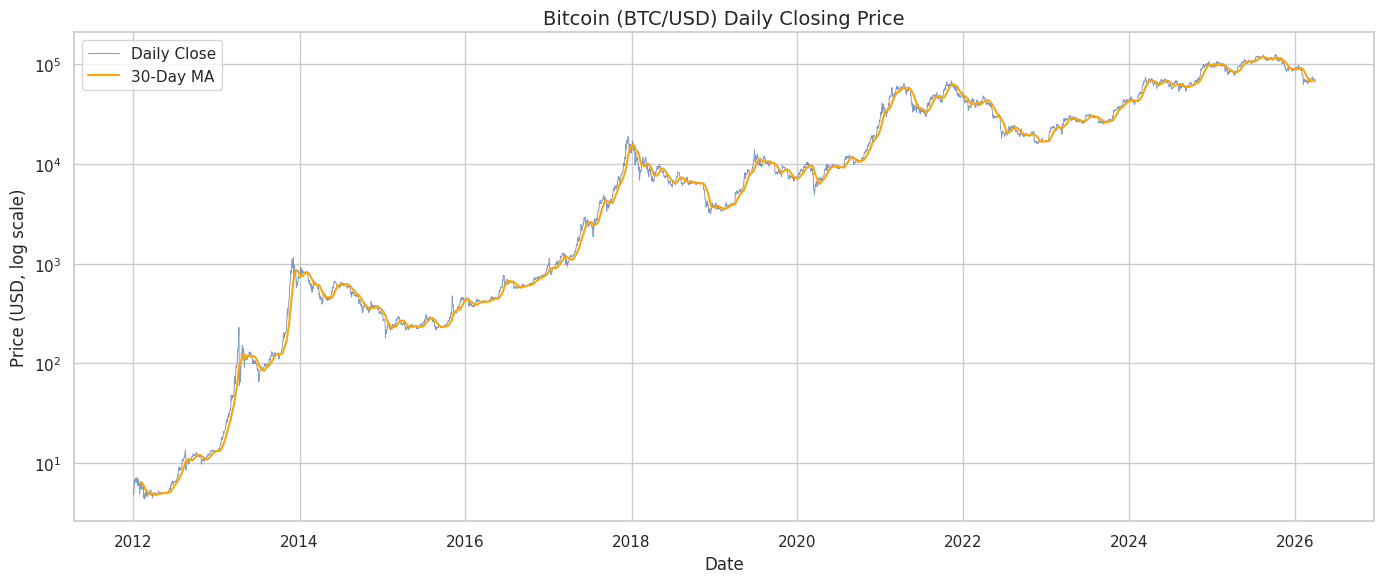

Earliest price: $4.84 on 2012-01-01
Highest price:  $124,728.00 on 2025-10-06
Latest price:   $66,356.00 on 2026-03-28


In [ ]:
# Chart 1: Bitcoin closing price over time with 30-day moving average
# -------------------------------------------------------------------
# We plot the raw daily close alongside its 30-day moving average.
# The log-scale y-axis lets us see early price movements clearly,
# since Bitcoin went from ~$5 to tens of thousands.

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df["Close"], linewidth=0.7, alpha=0.7, label="Daily Close")
ax.plot(df.index, df["MA_30"], linewidth=1.5, color="orange", label="30-Day MA")

ax.set_yscale("log")
ax.set_title("Bitcoin (BTC/USD) Daily Closing Price", fontsize=14)
ax.set_ylabel("Price (USD, log scale)")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()

# Key milestones
print(f"Earliest price: ${df['Close'].iloc[0]:,.2f} on {df.index[0].date()}")
print(f"Highest price:  ${df['Close'].max():,.2f} on {df['Close'].idxmax().date()}")
print(f"Latest price:   ${df['Close'].iloc[-1]:,.2f} on {df.index[-1].date()}")

---

### Chart 2: Average Daily Return by Day of the Week

**What we're looking at:** The average daily percentage return for each day of the week (Monday through Sunday). Bitcoin trades 24/7, so all seven days are included.

**Why it matters:** If certain days consistently show higher or lower returns, it could hint at systematic trading patterns (e.g., institutional activity on weekdays vs. retail on weekends).

**What to look for:**
- Are any days consistently positive or negative?
- Is there a "weekend effect" in Bitcoin?
- How large are the differences between days?

> **Beginner tip:** A bar chart is great for comparing a number (like an average) across categories. Taller bar = higher value for that group.

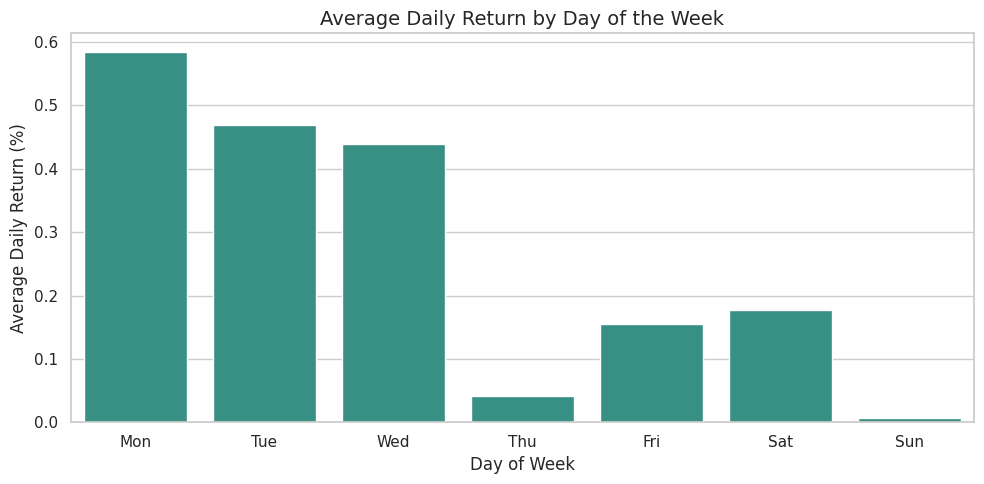

Average daily return per day:
  Mon: +0.5845%
  Tue: +0.4693%
  Wed: +0.4398%
  Thu: +0.0407%
  Fri: +0.1553%
  Sat: +0.1776%
  Sun: +0.0064%


In [ ]:
# Chart 2: Average daily return by day of the week
# -------------------------------------------------
# We group all daily returns by day of the week and compute the mean.
# This reveals whether certain days have systematically different returns.

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
day_returns = df.dropna(subset=["Daily_Return"]).groupby("Day_of_Week")["Daily_Return"].mean()

plt.figure(figsize=(10, 5))

colors = ["#2a9d8f" if v >= 0 else "#e76f51" for v in day_returns.values]

sns.barplot(
    x=day_labels,
    y=day_returns.values,
    palette=colors,
)

plt.title("Average Daily Return by Day of the Week", fontsize=14)
plt.ylabel("Average Daily Return (%)")
plt.xlabel("Day of Week")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

print("Average daily return per day:")
for i, label in enumerate(day_labels):
    print(f"  {label}: {day_returns.values[i]:+.4f}%")

---

### Chart 3: Distribution of Daily Returns

**What we're looking at:** This histogram shows how daily percentage returns are distributed across all trading days. The smooth curve (KDE) highlights the shape of the distribution.

**Why it matters:** Understanding the return distribution tells us about risk. If the tails are heavy (lots of extreme moves), Bitcoin is more volatile and risky than a normally-distributed asset.

**What to look for:**
- Is the distribution centered near zero? (Expected for daily returns)
- Are the tails fat? (Many extreme gains/losses)
- Is it roughly symmetric, or does it lean to one side?

> **Beginner tip:** A histogram groups values into ranges (bins) and counts how many fall in each. It's one of the most useful charts for understanding a variable at a glance.

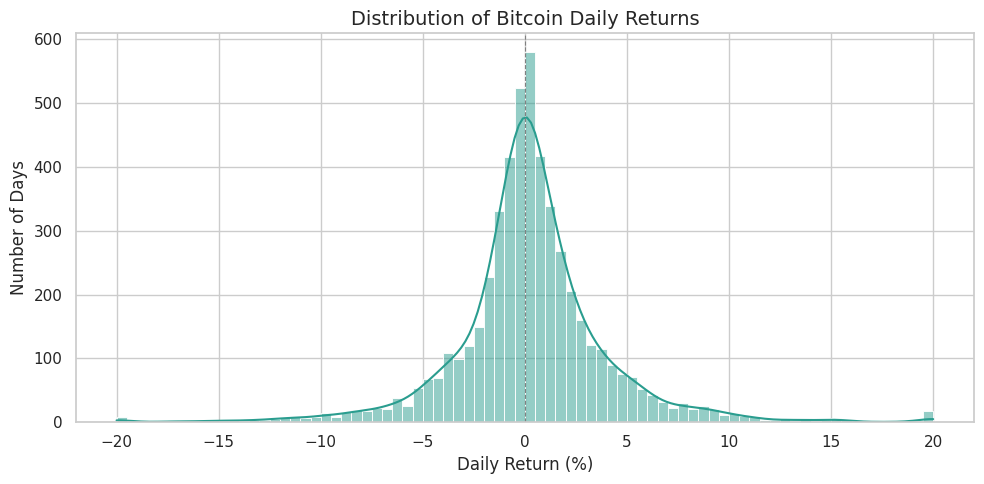

Summary statistics for Daily Returns:
count    5200.0000
mean        0.2677
std         4.0542
min       -53.8385
25%        -1.2459
50%         0.1484
75%         1.7466
max        35.8107
Name: Daily_Return, dtype: float64

Skewness: -0.3468
Kurtosis: 15.8644
(High kurtosis = fat tails = more extreme moves than a normal distribution)


In [ ]:
# Chart 3: Distribution of daily returns
# ----------------------------------------
# We clip extreme outliers for a cleaner histogram, but still report the full range.
# kde=True adds a smoothed density curve on top.

returns = df["Daily_Return"].dropna()

plt.figure(figsize=(10, 5))

sns.histplot(
    returns.clip(-20, 20),
    bins=80,
    kde=True,
    color="#2a9d8f",
)

plt.title("Distribution of Bitcoin Daily Returns", fontsize=14)
plt.xlabel("Daily Return (%)")
plt.ylabel("Number of Days")
plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

print("Summary statistics for Daily Returns:")
print(returns.describe().round(4))
print(f"\nSkewness: {returns.skew():.4f}")
print(f"Kurtosis: {returns.kurtosis():.4f}")
print("(High kurtosis = fat tails = more extreme moves than a normal distribution)")

## Additional Insights

Let's dig deeper with a few more visualizations to uncover patterns.

### Yearly Returns & Volatility

How did Bitcoin perform each year, and how volatile was it?

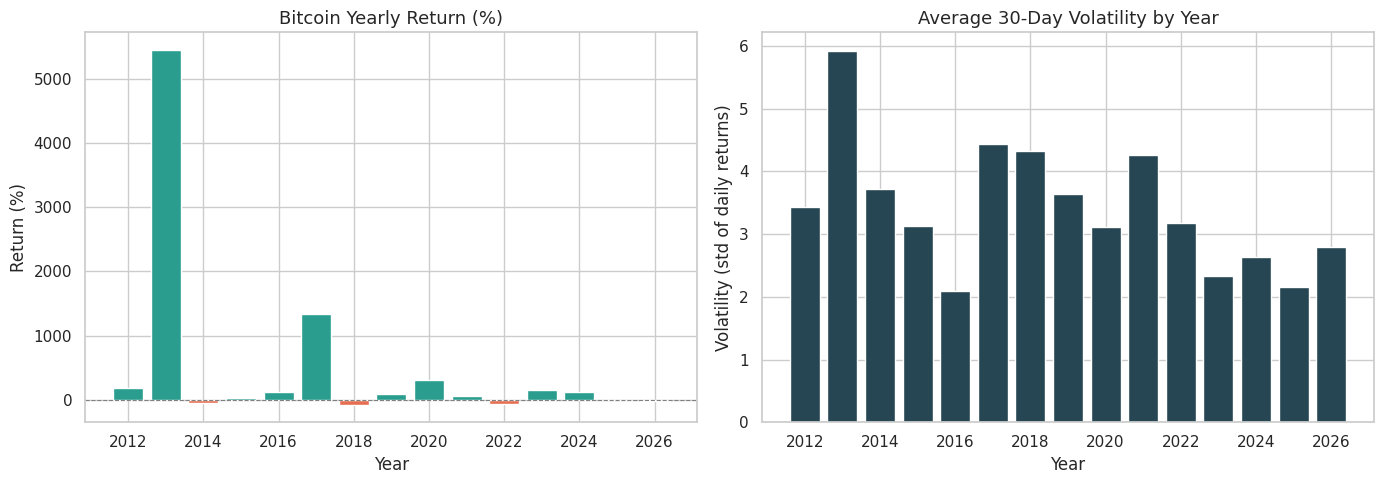

Yearly summary:


,Yearly_Return_Pct,Avg_Volatility,High,Low
Year,,,,
2012,189.08,3.43,16.41,3.80
2013,5446.30,5.92,1163.00,12.77
2014,-56.88,3.73,995.00,275.00
2015,36.19,3.13,502.00,152.40
2016,123.52,2.09,980.74,352.00
2017,1333.63,4.43,19666.00,751.34
2018,-72.90,4.33,17234.99,3122.28
2019,90.36,3.64,13880.00,3322.19
2020,304.77,3.12,29300.00,3850.00


In [ ]:
# Yearly summary: total return and average volatility
yearly = df.groupby("Year").agg(
    Open=("Open", "first"),
    Close=("Close", "last"),
    High=("High", "max"),
    Low=("Low", "min"),
    Avg_Volatility=("Volatility_30d", "mean"),
    Total_Volume=("Volume", "sum"),
)
yearly["Yearly_Return_Pct"] = ((yearly["Close"] - yearly["Open"]) / yearly["Open"]) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Yearly return bar chart
colors_yr = ["#2a9d8f" if v >= 0 else "#e76f51" for v in yearly["Yearly_Return_Pct"]]
axes[0].bar(yearly.index, yearly["Yearly_Return_Pct"], color=colors_yr)
axes[0].set_title("Bitcoin Yearly Return (%)", fontsize=13)
axes[0].set_ylabel("Return (%)")
axes[0].set_xlabel("Year")
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle="--")

# Yearly volatility
axes[1].bar(yearly.index, yearly["Avg_Volatility"], color="#264653")
axes[1].set_title("Average 30-Day Volatility by Year", fontsize=13)
axes[1].set_ylabel("Volatility (std of daily returns)")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.show()

print("Yearly summary:")
display(yearly[["Yearly_Return_Pct", "Avg_Volatility", "High", "Low"]].round(2))

### Monthly Heatmap of Average Returns

Are there months that tend to be bullish or bearish for Bitcoin?

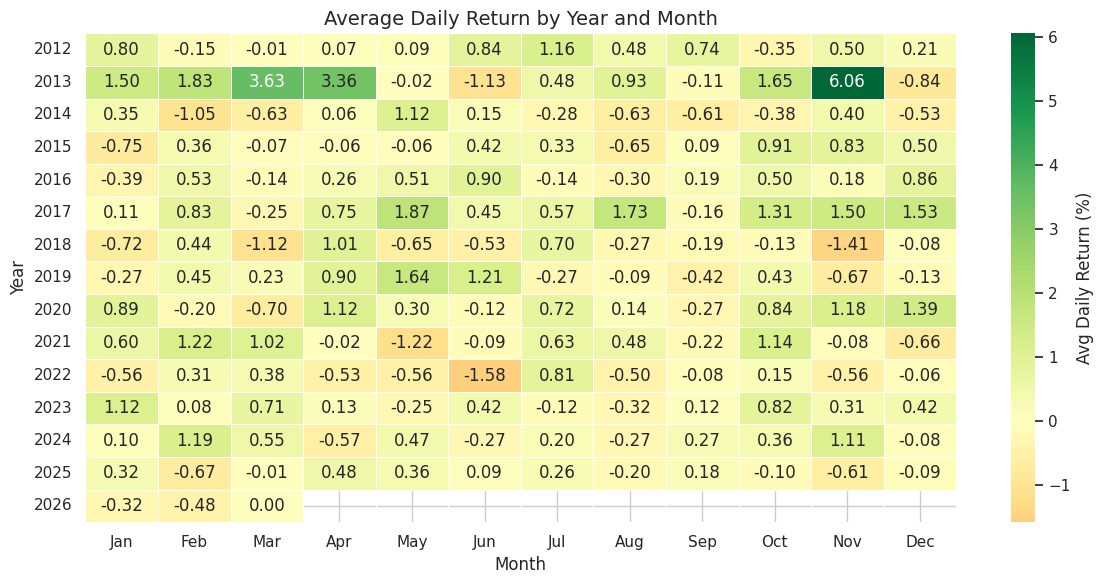

In [ ]:
# Monthly average returns heatmap (Year x Month)
monthly_returns = df.dropna(subset=["Daily_Return"]).groupby(["Year", "Month"])["Daily_Return"].mean().unstack()
monthly_returns.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"][:len(monthly_returns.columns)]

plt.figure(figsize=(12, 6))
sns.heatmap(
    monthly_returns,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Avg Daily Return (%)"},
)
plt.title("Average Daily Return by Year and Month", fontsize=14)
plt.ylabel("Year")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

### Rolling Volatility Over Time

How has Bitcoin's risk profile changed over the years?

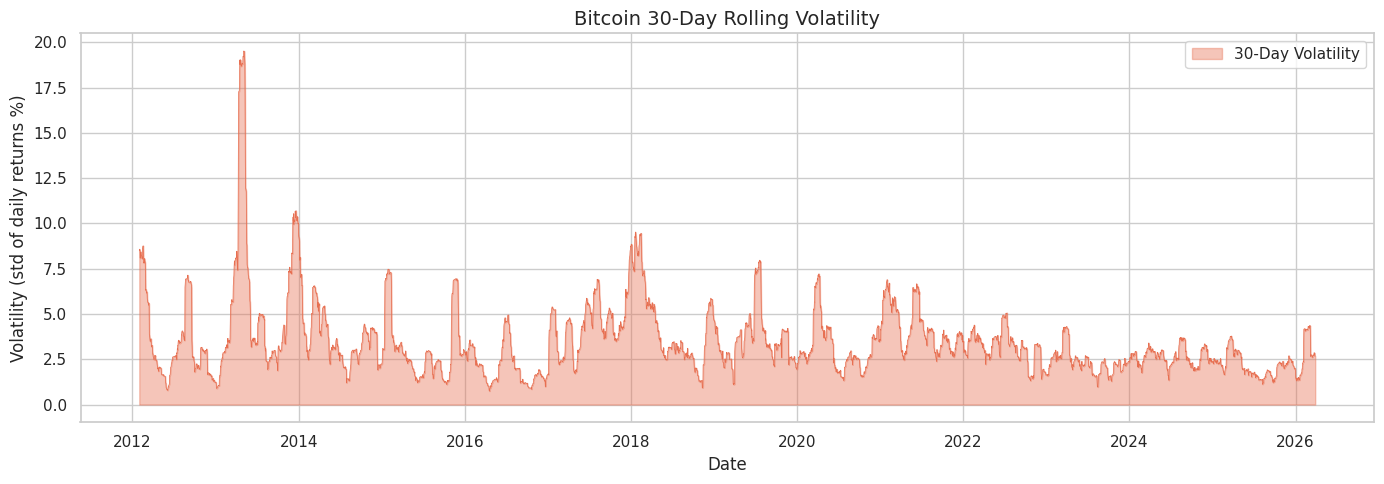

Average volatility: 3.44%
Max volatility:     19.52% on 2013-05-04


In [ ]:
# Rolling 30-day volatility plotted over time
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df.index, df["Volatility_30d"], alpha=0.4, color="#e76f51", label="30-Day Volatility")
ax.plot(df.index, df["Volatility_30d"], linewidth=0.5, color="#e76f51")

ax.set_title("Bitcoin 30-Day Rolling Volatility", fontsize=14)
ax.set_ylabel("Volatility (std of daily returns %)")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Average volatility: {df['Volatility_30d'].mean():.2f}%")
print(f"Max volatility:     {df['Volatility_30d'].max():.2f}% on {df['Volatility_30d'].idxmax().date()}")

## Baseline Machine Learning Model

Goal: predict whether Bitcoin's price will go **up or down** the next day using recent price and volume features.

This is a baseline classification model, not a trading strategy.

In [ ]:
# Prepare features for next-day direction prediction
ml_df = df.copy()

# Target: 1 if next day's return is positive, 0 otherwise
ml_df["Target"] = (ml_df["Close"].shift(-1) > ml_df["Close"]).astype(int)

# Lag features: use past data only (no look-ahead bias)
ml_df["Return_1d"] = ml_df["Daily_Return"]
ml_df["Return_3d"] = ml_df["Close"].pct_change(3) * 100
ml_df["Return_7d"] = ml_df["Close"].pct_change(7) * 100
ml_df["Vol_Ratio"] = ml_df["Volume"] / ml_df["Volume"].rolling(7).mean()
ml_df["Price_vs_MA30"] = ((ml_df["Close"] - ml_df["MA_30"]) / ml_df["MA_30"]) * 100
ml_df["Range_Pct"] = ml_df["Intraday_Range_Pct"]

feature_cols = [
    "Return_1d", "Return_3d", "Return_7d",
    "Volatility_30d", "Vol_Ratio", "Price_vs_MA30", "Range_Pct",
    "Day_of_Week",
]

ml_df = ml_df.dropna(subset=feature_cols + ["Target"])

X = ml_df[feature_cols]
y = ml_df["Target"]

print(f"Samples: {len(X):,}")
print(f"Features: {feature_cols}")
print(f"Class balance: {y.value_counts().to_dict()}")

Samples: 5,171
Features: ['Return_1d', 'Return_3d', 'Return_7d', 'Volatility_30d', 'Vol_Ratio', 'Price_vs_MA30', 'Range_Pct', 'Day_of_Week']
Class balance: {1: 2749, 0: 2422}


In [ ]:
# Train / Test split (time-based: train on earlier data, test on later)
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train):,} samples ({X_train.index.min().date()} to {X_train.index.max().date()})")
print(f"Test:  {len(X_test):,} samples ({X_test.index.min().date()} to {X_test.index.max().date()})")

# Build pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=-1,
    )),
])

pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)

acc = accuracy_score(y_test, preds)
print(f"\nAccuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, preds, target_names=["Down", "Up"]))

Train: 4,136 samples (2012-01-31 to 2023-05-28)
Test:  1,035 samples (2023-05-29 to 2026-03-28)

Accuracy: 0.5092

Classification Report:
              precision    recall  f1-score   support

        Down       0.50      0.27      0.36       510
          Up       0.51      0.74      0.60       525

    accuracy                           0.51      1035
   macro avg       0.51      0.51      0.48      1035
weighted avg       0.51      0.51      0.48      1035



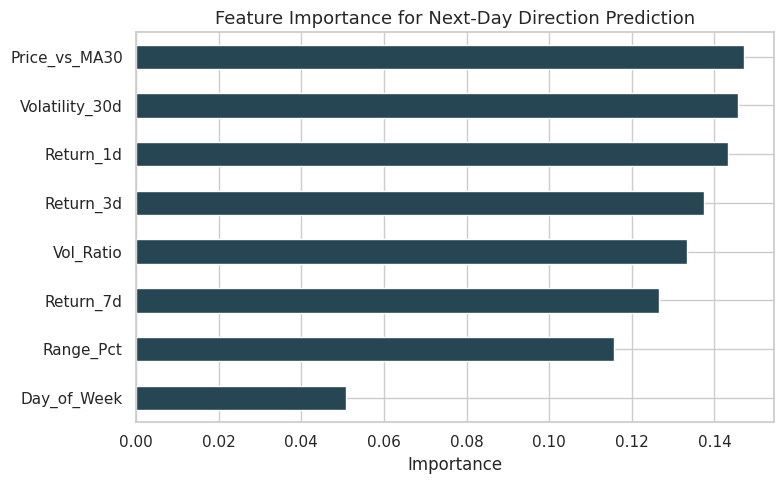

Feature importances (sorted):
Price_vs_MA30     0.1471
Volatility_30d    0.1457
Return_1d         0.1433
Return_3d         0.1374
Vol_Ratio         0.1334
Return_7d         0.1265
Range_Pct         0.1158
Day_of_Week       0.0508


In [ ]:
# Feature importance
importances = pipeline.named_steps["model"].feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.plot.barh(color="#264653")
plt.title("Feature Importance for Next-Day Direction Prediction", fontsize=13)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Feature importances (sorted):")
print(feat_imp.sort_values(ascending=False).round(4).to_string())

## How to Use This Analysis

### What This Notebook Shows:

The analysis explores Bitcoin's historical price data from multiple angles:

1. **Long-term trend** - Bitcoin's price trajectory over time, showing exponential growth punctuated by major corrections.
2. **Day-of-week effects** - Whether certain days show systematically different returns.
3. **Return distribution** - The statistical properties of Bitcoin's daily moves, including fat tails (more extreme moves than expected).
4. **Seasonality** - Year-by-year and month-by-month patterns in returns.
5. **Volatility regimes** - How Bitcoin's risk profile has evolved over time.
6. **Baseline model** - A Random Forest classifier predicting next-day price direction.

### Key Takeaways:

- Bitcoin's return distribution has heavy tails (high kurtosis), meaning extreme daily moves occur more often than a normal distribution would predict.
- Volatility tends to cluster: periods of high volatility are followed by more high volatility.
- Predicting next-day direction is hard (close to 50/50), which is consistent with the efficient market hypothesis.

### Key Limitations:

- **Past performance does not predict future results.** Historical patterns may not persist.
- **Correlation is not causation.** Seasonal or day-of-week patterns may be coincidental.
- The baseline ML model is intentionally simple and is NOT a trading strategy.
- Bitcoin markets have changed dramatically over time (liquidity, regulation, participants), so patterns from early years may not apply to recent years.

### Your Presentation Story:

1. **Question**: What patterns exist in Bitcoin's historical trading data?
2. **Data**: Used minute-level BTC/USD data spanning multiple years, aggregated to daily bars.
3. **EDA**: Found exponential price growth, fat-tailed returns, and evolving volatility regimes.
4. **Model**: Built a Random Forest to predict next-day direction (accuracy ~ 50%).
5. **Evidence**: Show price charts, return distributions, volatility trends, and feature importance.
6. **Conclusion**: Bitcoin exhibits high volatility with heavy tails; short-term direction is hard to predict from price data alone.
7. **Limits**: Acknowledge survivorship bias, changing market structure, and correlation vs. causation.